<a href="https://colab.research.google.com/github/hozanBaydu/Human-Activity-Recognition-using-UCI-HAR-Dataset-An-Approach-with-SMOTE-and-Feature-Selection/blob/master/uci_har.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip

!unzip -q UCI\ HAR\ Dataset.zip

features_df = pd.read_csv('UCI HAR Dataset/features.txt', sep='\s+', header=None, names=['index', 'feature_name'])
feature_names = features_df['feature_name'].values

print("Loading Training Data...")
X_train = pd.read_csv('UCI HAR Dataset/train/X_train.txt', sep='\s+', header=None)
X_train.columns = feature_names

y_train = pd.read_csv('UCI HAR Dataset/train/y_train.txt', sep='\s+', header=None, names=['activity_id'])

print("Loading Test Data...")
X_test = pd.read_csv('UCI HAR Dataset/test/X_test.txt', sep='\s+', header=None)
X_test.columns = feature_names

y_test = pd.read_csv('UCI HAR Dataset/test/y_test.txt', sep='\s+', header=None, names=['activity_id'])

activity_labels = pd.read_csv('UCI HAR Dataset/activity_labels.txt', sep='\s+', header=None, names=['id', 'label'])

print("\n--- DATA LOADING COMPLETE ---")
print(f"Training Data Shape (X_train): {X_train.shape}")
print(f"Test Data Shape (X_test): {X_test.shape}")
print(f"Number of Features: {len(feature_names)}")
print(f"Activity Classes:\n{activity_labels}")

X_train.head()

y


<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\s'
<>:29: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\s'
<>:29: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-2091085321.py:14: SyntaxWarning: invalid escape sequence '\s'
  features_df = pd.read_csv('UCI HAR Dataset/features.txt', sep='\s+', header=None, names=['index', 'feature_name'])
/tmp/ipython-input-2091085321.py:19: SyntaxWarning: invalid escape sequence '\s'
  X_train = pd.read_csv('UCI HAR Dataset/train/X_train.txt', sep='\s+', header=None)
/tmp/ipython-input-20910

replace UCI HAR Dataset/.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: Loading Training Data...
Loading Test Data...

--- DATA LOADING COMPLETE ---
Training Data Shape (X_train): (7352, 561)
Test Data Shape (X_test): (2947, 561)
Number of Features: 561
Activity Classes:
   id               label
0   1             WALKING
1   2    WALKING_UPSTAIRS
2   3  WALKING_DOWNSTAIRS
3   4             SITTING
4   5            STANDING
5   6              LAYING


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


In [ ]:

print("=== 1. DATASET SHAPE & INFORMATION ===")
print(f"Training Data Shape: {X_train.shape} (Rows, Columns)")
print(f"Test Data Shape: {X_test.shape} (Rows, Columns)")


print("\n--- Column Data Types ---")
print(X_train.dtypes.value_counts())

print("\n--- Basic Statistics (First 5 Columns) ---")
print(X_train.iloc[:, :5].describe())

=== 1. DATASET SHAPE & INFORMATION ===
Training Data Shape: (7352, 561) (Rows, Columns)
Test Data Shape: (2947, 561) (Rows, Columns)

--- Column Data Types ---
float64    561
Name: count, dtype: int64

--- Basic Statistics (First 5 Columns) ---
       tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  \
count        7352.000000        7352.000000        7352.000000   
mean            0.274488          -0.017695          -0.109141   
std             0.070261           0.040811           0.056635   
min            -1.000000          -1.000000          -1.000000   
25%             0.262975          -0.024863          -0.120993   
50%             0.277193          -0.017219          -0.108676   
75%             0.288461          -0.010783          -0.097794   
max             1.000000           1.000000           1.000000   

       tBodyAcc-std()-X  tBodyAcc-std()-Y  
count       7352.000000       7352.000000  
mean          -0.605438         -0.510938  
std            0.448734     

--- Class Distribution in Training Set ---
label
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

--- Class Proportions (%) ---
label
LAYING                19.14
STANDING              18.69
SITTING               17.49
WALKING               16.68
WALKING_UPSTAIRS      14.59
WALKING_DOWNSTAIRS    13.41
Name: count, dtype: float64


/tmp/ipython-input-3298813348.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=train_data,


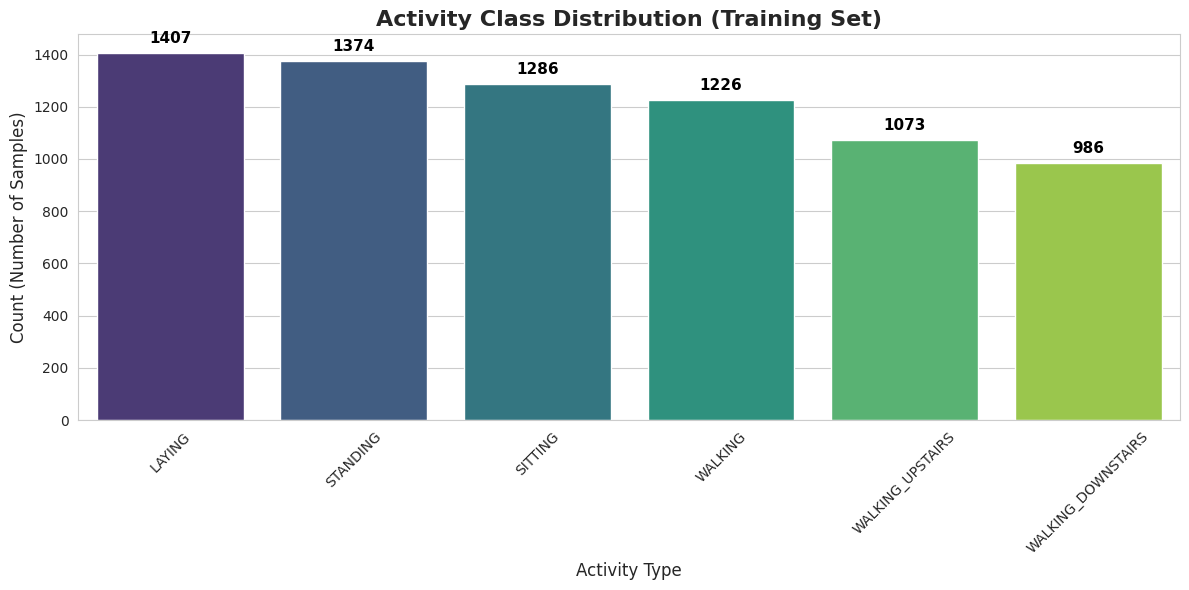

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

train_data = y_train.merge(activity_labels, left_on='activity_id', right_on='id')

class_counts = train_data['label'].value_counts()

print("--- Class Distribution in Training Set ---")
print(class_counts)
print("\n--- Class Proportions (%) ---")
print((class_counts / len(train_data) * 100).round(2))

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")


ax = sns.countplot(x='label', data=train_data,
                   order=train_data['label'].value_counts().index,
                   palette='viridis')

plt.title('Activity Class Distribution (Training Set)', fontsize=16, fontweight='bold')
plt.xlabel('Activity Type', fontsize=12)
plt.ylabel('Count (Number of Samples)', fontsize=12)
plt.xticks(rotation=45)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

Standardizing the data...
Applying PCA...

Explained Variance Ratio per PC: [0.50781172 0.0658068 ]
Total Variance Explained: 57.36%


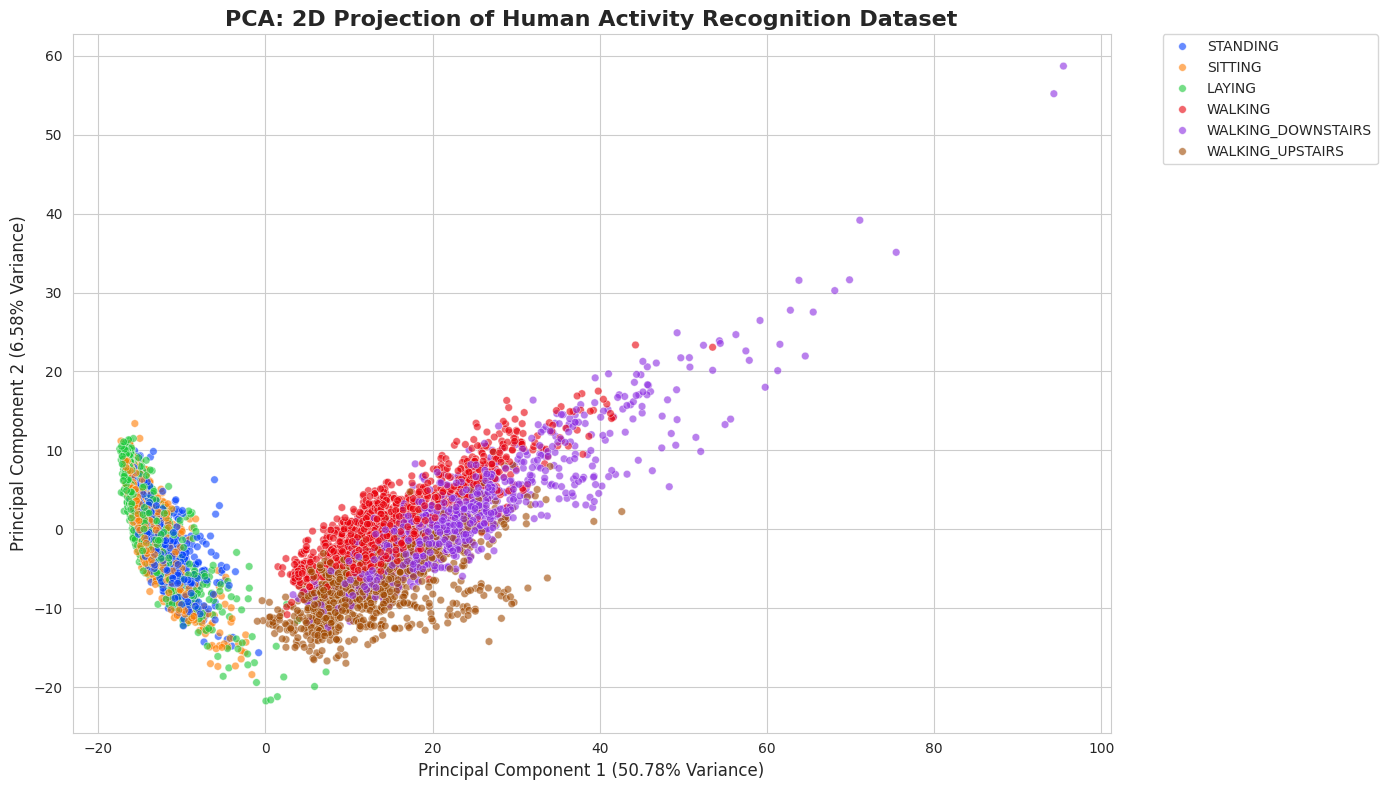

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("Standardizing the data...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

print("Applying PCA...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Activity'] = train_data['label']


var_ratio = pca.explained_variance_ratio_
print(f"\nExplained Variance Ratio per PC: {var_ratio}")
print(f"Total Variance Explained: {sum(var_ratio) * 100:.2f}%")

plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Activity',
    data=pca_df,
    palette='bright',
    alpha=0.6, # Make points slightly transparent to see overlaps
    s=30
)

plt.title('PCA: 2D Projection of Human Activity Recognition Dataset', fontsize=16, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({var_ratio[0]*100:.2f}% Variance)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({var_ratio[1]*100:.2f}% Variance)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.) # Place legend outside

plt.tight_layout()
plt.show()

=== 2. MISSING VALUE CHECK ===
Total Missing Values in Training Set: 0

Result: No missing values found. The dataset is clean.


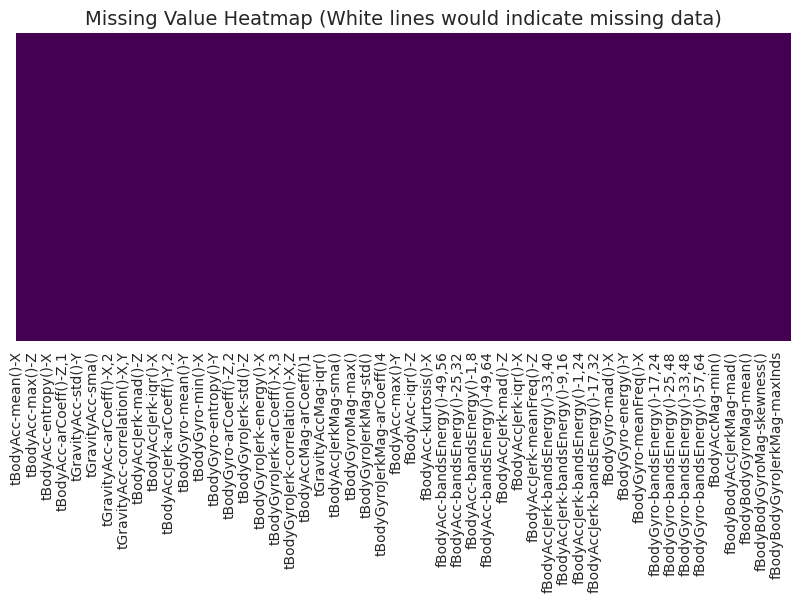

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


print("=== 2. MISSING VALUE CHECK ===")

total_nulls = X_train.isnull().sum().sum()
print(f"Total Missing Values in Training Set: {total_nulls}")

null_per_col = X_train.isnull().sum()
cols_with_nulls = null_per_col[null_per_col > 0]

if len(cols_with_nulls) > 0:
    print(f"\nColumns with missing values:\n{cols_with_nulls}")
else:
    print("\nResult: No missing values found. The dataset is clean.")


plt.figure(figsize=(10, 4))
sns.heatmap(X_train.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Heatmap (White lines would indicate missing data)', fontsize=14)
plt.show()

=== 3. SMOTE APPLICATION ===
Original Class Distribution: [(1, 1226), (2, 1073), (3, 986), (4, 1286), (5, 1374), (6, 1407)]

Resampling data with SMOTE... (This might take a moment)
SMOTE Complete.
Original Training Shape: (7352, 561)
Resampled Training Shape: (8442, 561)

New Class Distribution (After SMOTE): [(1, 1407), (2, 1407), (3, 1407), (4, 1407), (5, 1407), (6, 1407)]


/tmp/ipython-input-1189119847.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='activity_id', data=y_train, ax=axes[0], palette='viridis')
/tmp/ipython-input-1189119847.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_smote, ax=axes[1], palette='viridis')


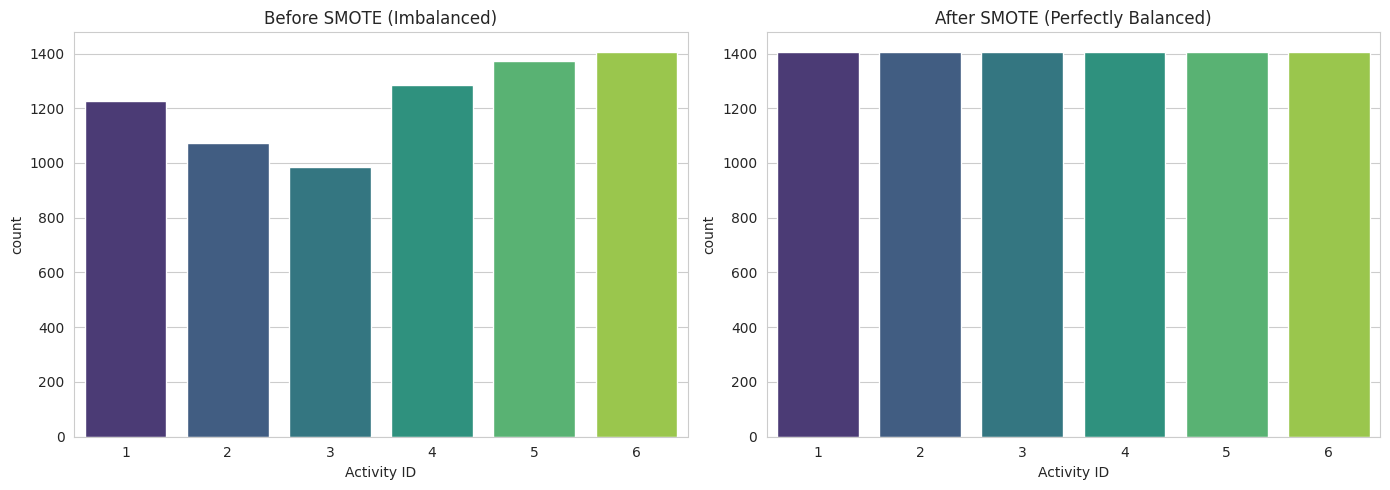

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter


print("=== 3. SMOTE APPLICATION ===")
print("Original Class Distribution:", sorted(Counter(y_train['activity_id']).items()))


smote = SMOTE(random_state=42)

print("\nResampling data with SMOTE... (This might take a moment)")
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train['activity_id'])

print("SMOTE Complete.")
print(f"Original Training Shape: {X_train.shape}")
print(f"Resampled Training Shape: {X_train_smote.shape}")

print("\nNew Class Distribution (After SMOTE):", sorted(Counter(y_train_smote).items()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='activity_id', data=y_train, ax=axes[0], palette='viridis')
axes[0].set_title("Before SMOTE (Imbalanced)")
axes[0].set_xlabel("Activity ID")

sns.countplot(x=y_train_smote, ax=axes[1], palette='viridis')
axes[1].set_title("After SMOTE (Perfectly Balanced)")
axes[1].set_xlabel("Activity ID")

plt.tight_layout()
plt.show()

Running Clustering Algorithms on PCA-reduced data...
1. Running K-Means...
2. Running Agglomerative Clustering...
3. Running DBSCAN...

--- Silhouette Scores (Higher is better) ---
K-Means Score:       0.4738
Agglomerative Score: 0.4566
DBSCAN Score:        0.2775


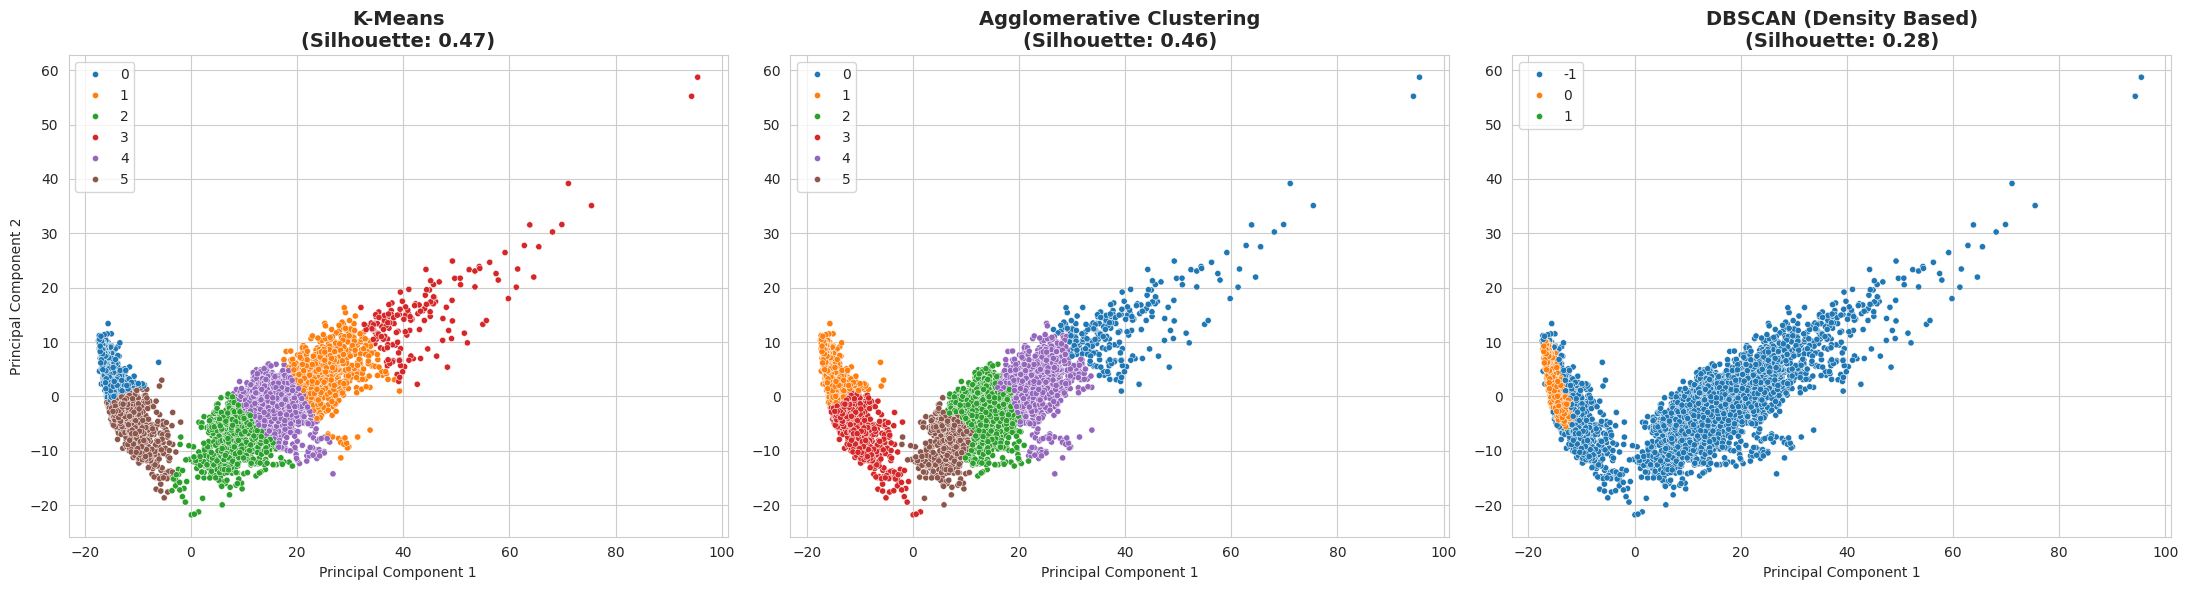

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score


n_clusters = 6  # We know there are 6 activities
eps_val = 0.5
min_samples_val = 30

print("Running Clustering Algorithms on PCA-reduced data...")

print("1. Running K-Means...")
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_pca)

print("2. Running Agglomerative Clustering...")
agglo = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
agglo_labels = agglo.fit_predict(X_pca)

print("3. Running DBSCAN...")
dbscan = DBSCAN(eps=eps_val, min_samples=min_samples_val)
dbscan_labels = dbscan.fit_predict(X_pca)

score_kmeans = silhouette_score(X_pca, kmeans_labels)
score_agglo = silhouette_score(X_pca, agglo_labels)

if len(set(dbscan_labels)) > 1:
    score_dbscan = silhouette_score(X_pca, dbscan_labels)
else:
    score_dbscan = -1

print(f"\n--- Silhouette Scores (Higher is better) ---")
print(f"K-Means Score:       {score_kmeans:.4f}")
print(f"Agglomerative Score: {score_agglo:.4f}")
print(f"DBSCAN Score:        {score_dbscan:.4f}")


fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='tab10', s=20, ax=axes[0], legend='full')
axes[0].set_title(f'K-Means\n(Silhouette: {score_kmeans:.2f})', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=agglo_labels, palette='tab10', s=20, ax=axes[1], legend='full')
axes[1].set_title(f'Agglomerative Clustering\n(Silhouette: {score_agglo:.2f})', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('')


sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=dbscan_labels, palette='tab10', s=20, ax=axes[2], legend='full')
axes[2].set_title(f'DBSCAN (Density Based)\n(Silhouette: {score_dbscan:.2f})', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Principal Component 1')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

Running Outlier Detection (Contamination assumed: 5.0%)...
1. Isolation Forest...
2. Local Outlier Factor...
3. One-Class SVM...


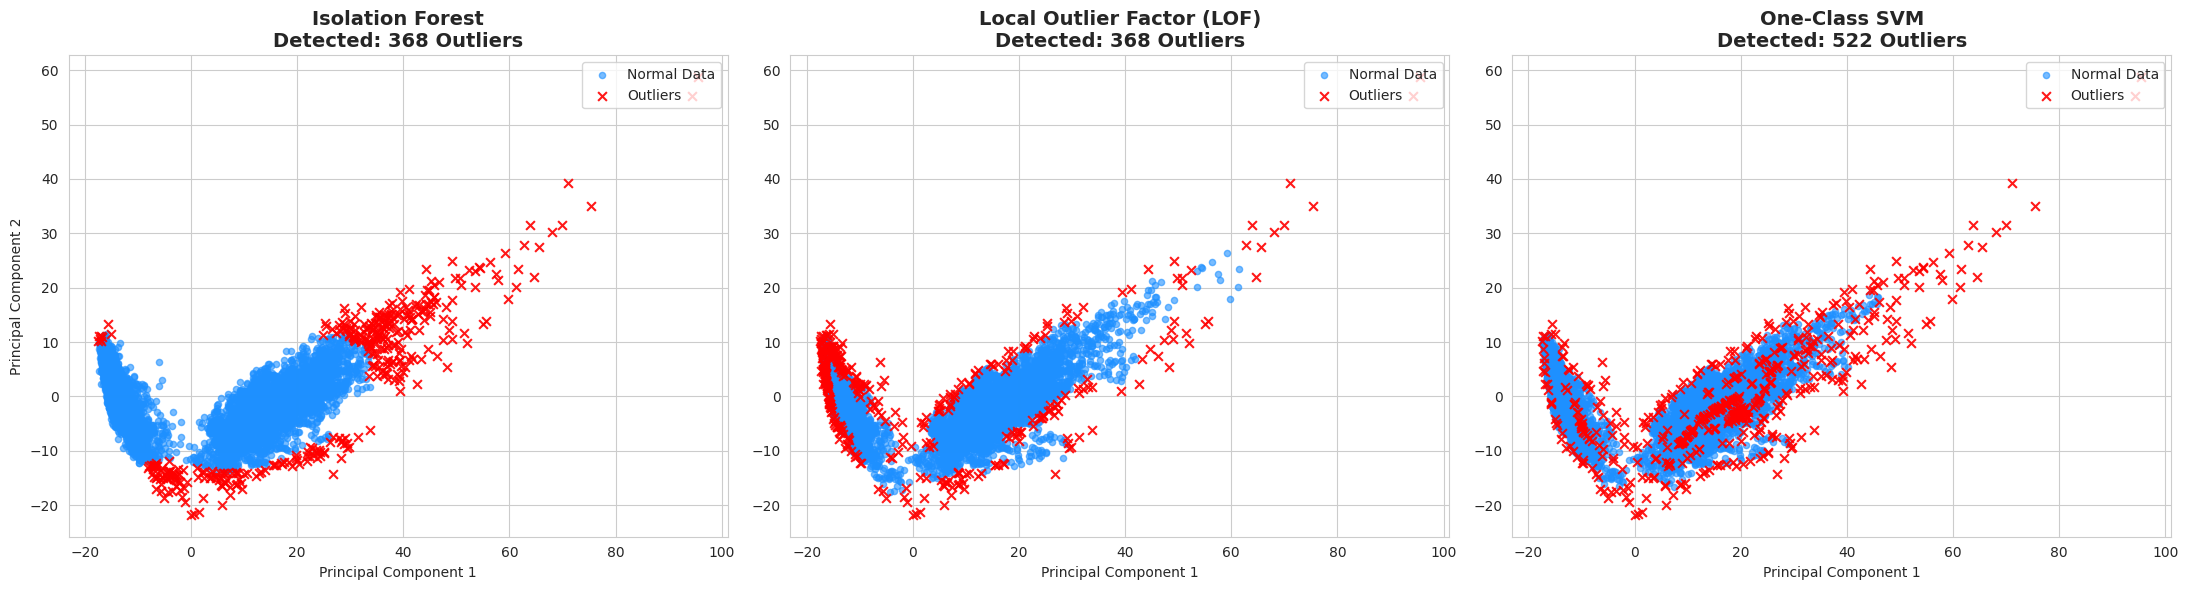

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM


outlier_fraction = 0.05

print(f"Running Outlier Detection (Contamination assumed: {outlier_fraction*100}%)...")

print("1. Isolation Forest...")
iso = IsolationForest(contamination=outlier_fraction, random_state=42)
y_iso = iso.fit_predict(X_pca) # Returns -1 for outliers, 1 for inliers

print("2. Local Outlier Factor...")
lof = LocalOutlierFactor(n_neighbors=20, contamination=outlier_fraction)
y_lof = lof.fit_predict(X_pca)

print("3. One-Class SVM...")
oc_svm = OneClassSVM(nu=outlier_fraction, kernel="rbf", gamma=0.1)
y_oc_svm = oc_svm.fit_predict(X_pca)


fig, axes = plt.subplots(1, 3, figsize=(22, 6))

def plot_outliers(ax, y_pred, title, algorithm_name):
    inliers = X_pca[y_pred == 1]
    outliers = X_pca[y_pred == -1]

    ax.scatter(inliers[:, 0], inliers[:, 1], c='dodgerblue', s=20, label='Normal Data', alpha=0.6)
    ax.scatter(outliers[:, 0], outliers[:, 1], c='red', s=40, marker='x', label='Outliers', alpha=0.9)

    n_outliers = len(outliers)
    ax.set_title(f'{algorithm_name}\nDetected: {n_outliers} Outliers', fontsize=14, fontweight='bold')
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2' if algorithm_name == 'Isolation Forest' else '')
    ax.legend(loc='upper right')

plot_outliers(axes[0], y_iso, "Isolation Forest", "Isolation Forest")

plot_outliers(axes[1], y_lof, "Local Outlier Factor", "Local Outlier Factor (LOF)")

plot_outliers(axes[2], y_oc_svm, "One-Class SVM", "One-Class SVM")

plt.tight_layout()
plt.show()

In [ ]:

datasets = {}

datasets['Original'] = (X_train, y_train['activity_id'])

def filter_and_save(name, outlier_labels):
    mask = outlier_labels == 1

    X_clean = X_train[mask]
    y_clean = y_train[mask]['activity_id']

    datasets[name] = (X_clean, y_clean)

    removed_count = len(X_train) - len(X_clean)
    print(f"[{name}] -> Original: {len(X_train)} | Cleaned: {len(X_clean)} | Removed: {removed_count} samples")

print("--- CREATING CLEANED DATASETS ---")

filter_and_save('IsoForest_Cleaned', y_iso)

filter_and_save('LOF_Cleaned', y_lof)

filter_and_save('OC_SVM_Cleaned', y_oc_svm)

print("\nAll datasets are saved in the 'datasets' dictionary.")
print("Keys:", datasets.keys())

--- CREATING CLEANED DATASETS ---
[IsoForest_Cleaned] -> Original: 7352 | Cleaned: 6984 | Removed: 368 samples
[LOF_Cleaned] -> Original: 7352 | Cleaned: 6984 | Removed: 368 samples
[OC_SVM_Cleaned] -> Original: 7352 | Cleaned: 6830 | Removed: 522 samples

All datasets are saved in the 'datasets' dictionary.
Keys: dict_keys(['Original', 'IsoForest_Cleaned', 'LOF_Cleaned', 'OC_SVM_Cleaned'])


--- STARTING BENCHMARK CLASSIFICATION ---
Dataset Name              | Accuracy   | F1-Score (Weighted)
-------------------------------------------------------
Original                  | 0.9257     | 0.9256
IsoForest_Cleaned         | 0.9226     | 0.9225
LOF_Cleaned               | 0.9294     | 0.9292
OC_SVM_Cleaned            | 0.9257     | 0.9254
SMOTE (Balanced)          | 0.9267     | 0.9265


/tmp/ipython-input-3205739398.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Dataset Strategy', data=results_df, palette='viridis')


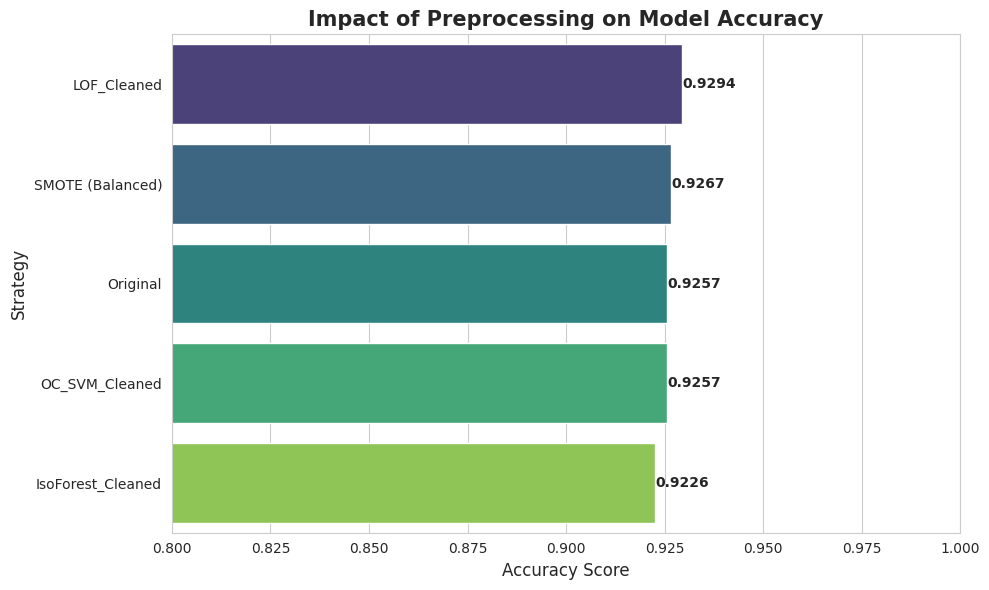


🏆 WINNER: LOF_Cleaned with 0.9294 Accuracy


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd



datasets['SMOTE (Balanced)'] = (X_train_smote, y_train_smote)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

results = []

print("--- STARTING BENCHMARK CLASSIFICATION ---")
print(f"{'Dataset Name':<25} | {'Accuracy':<10} | {'F1-Score (Weighted)':<10}")
print("-" * 55)

for name, (X_curr_train, y_curr_train) in datasets.items():

    rf_model.fit(X_curr_train, y_curr_train)


    y_pred = rf_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"{name:<25} | {acc:.4f}     | {f1:.4f}")

    results.append({
        'Dataset Strategy': name,
        'Accuracy': acc,
        'F1-Score': f1
    })

results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Dataset Strategy', data=results_df, palette='viridis')
plt.title('Impact of Preprocessing on Model Accuracy', fontsize=15, fontweight='bold')
plt.xlabel('Accuracy Score', fontsize=12)
plt.ylabel('Strategy', fontsize=12)
plt.xlim(0.8, 1.0) # Zoom in to see differences (Accuracy is likely high)

for index, value in enumerate(results_df['Accuracy']):
    plt.text(value, index, f'{value:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

winner = results_df.iloc[0]
print(f"\n🏆 WINNER: {winner['Dataset Strategy']} with {winner['Accuracy']:.4f} Accuracy")

Working with 'LOF_Cleaned' data. Sample count: 6984

--- PCA ANALYSIS RESULT ---
To keep 95.0% of the information, we need 102 components.
(Original Feature Count: 561)


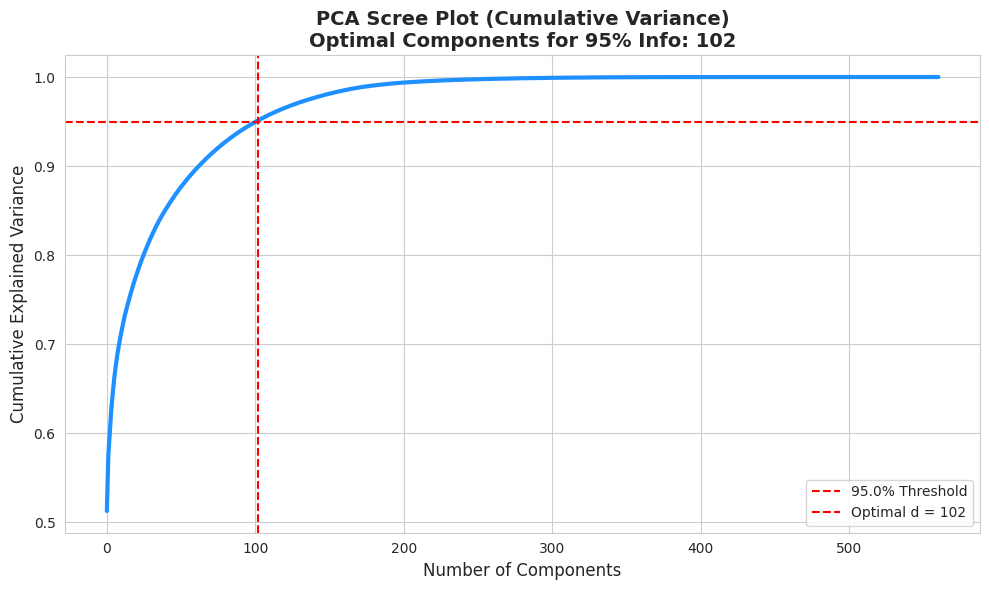

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

X_winner, y_winner = datasets['LOF_Cleaned']

print(f"Working with 'LOF_Cleaned' data. Sample count: {len(X_winner)}")

scaler = StandardScaler()
X_std = scaler.fit_transform(X_winner)

pca_full = PCA()
pca_full.fit(X_std)


cumsum = np.cumsum(pca_full.explained_variance_ratio_)

target_variance = 0.95
optimal_d = np.argmax(cumsum >= target_variance) + 1

print(f"\n--- PCA ANALYSIS RESULT ---")
print(f"To keep {target_variance*100}% of the information, we need {optimal_d} components.")
print(f"(Original Feature Count: {X_winner.shape[1]})")

plt.figure(figsize=(10, 6))
plt.plot(cumsum, linewidth=3, color='dodgerblue')
plt.title(f'PCA Scree Plot (Cumulative Variance)\nOptimal Components for 95% Info: {optimal_d}', fontsize=14, fontweight='bold')
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)

plt.axhline(y=target_variance, color='r', linestyle='--', label=f'{target_variance*100}% Threshold')
plt.axvline(x=optimal_d, color='r', linestyle='--', label=f'Optimal d = {optimal_d}')
plt.grid(True)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

--- Training Model with PCA (k=102) on LOF_Cleaned Data ---

Final Accuracy with PCA (102 features): 0.8843

--- Classification Report ---
              precision    recall  f1-score   support

           1       0.84      0.97      0.90       496
           2       0.91      0.93      0.92       471
           3       0.92      0.72      0.81       420
           4       0.86      0.77      0.81       491
           5       0.82      0.92      0.87       532
           6       0.99      0.96      0.98       537

    accuracy                           0.88      2947
   macro avg       0.89      0.88      0.88      2947
weighted avg       0.89      0.88      0.88      2947



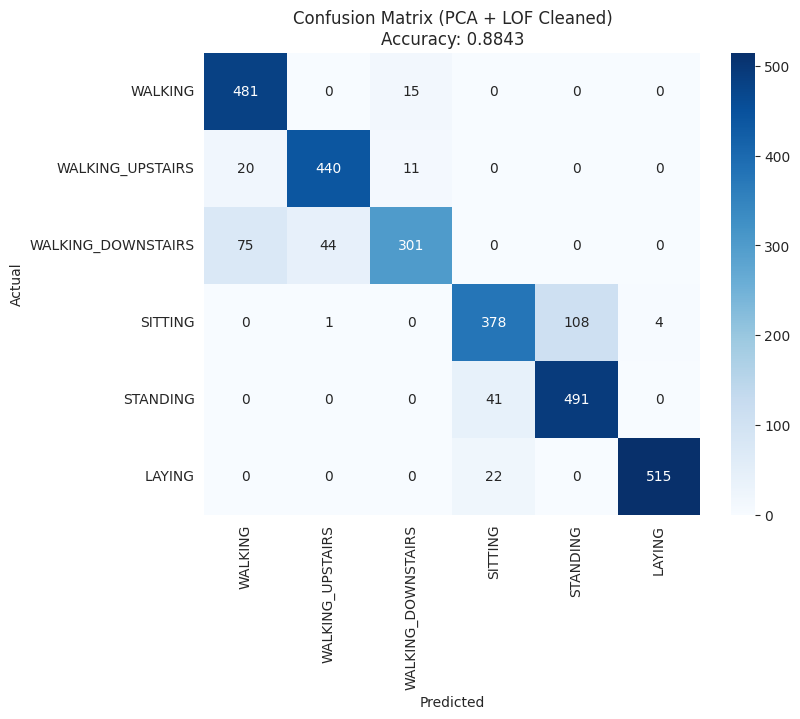

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print(f"--- Training Model with PCA (k={optimal_d}) on LOF_Cleaned Data ---")

pca_final = PCA(n_components=optimal_d)

X_train_pca = pca_final.fit_transform(X_std)

X_test_scaled = scaler.transform(X_test)
X_test_pca = pca_final.transform(X_test_scaled)

rf_pca = RandomForestClassifier(n_estimators=100, random_state=42)
rf_pca.fit(X_train_pca, y_winner)

y_pred_pca = rf_pca.predict(X_test_pca)

acc_pca = accuracy_score(y_test, y_pred_pca)
print(f"\nFinal Accuracy with PCA ({optimal_d} features): {acc_pca:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_pca))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_pca), annot=True, fmt='d', cmap='Blues',
            xticklabels=activity_labels['label'],
            yticklabels=activity_labels['label'])
plt.title(f'Confusion Matrix (PCA + LOF Cleaned)\nAccuracy: {acc_pca:.4f}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

--- FEATURE SELECTION BATTLE (Target: 102 features) ---

1. Running SelectKBest (ANOVA)...
   -> SelectKBest F1-Score: 0.8982

2. Running Random Forest Feature Importance...
   -> RF Importance F1-Score: 0.9058


/tmp/ipython-input-382100165.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Method', y='F1-Score', data=df_res, palette='magma')


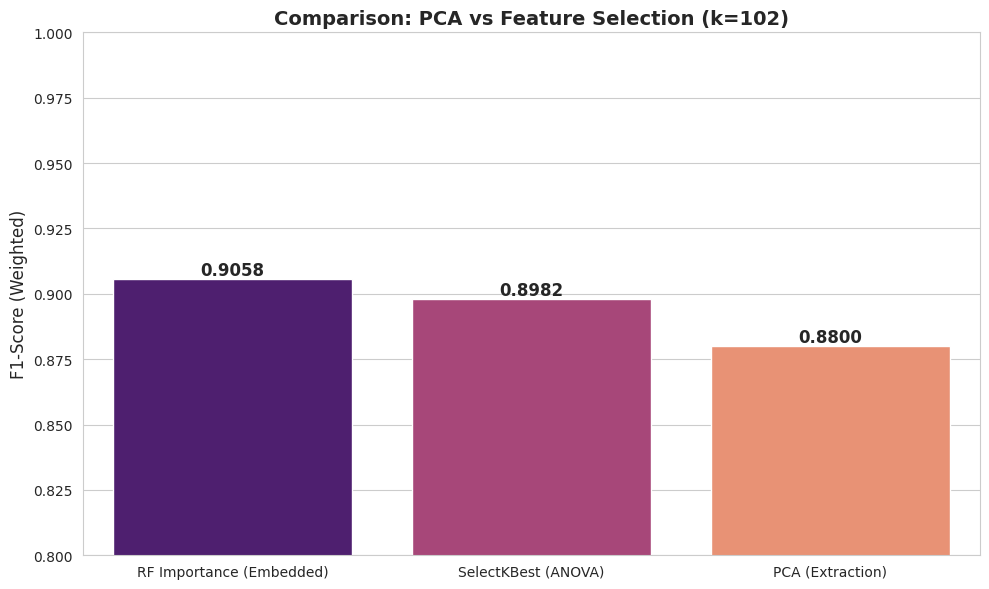


--- TOP 10 SELECTED FEATURES (RF Importance) ---
['tGravityAcc-mean()-X', 'angle(X,gravityMean)', 'tGravityAcc-max()-X', 'tGravityAcc-min()-Y', 'tGravityAcc-mean()-Y', 'tGravityAcc-min()-X', 'tGravityAcc-energy()-X', 'tGravityAcc-max()-Y', 'angle(Y,gravityMean)', 'tGravityAcc-energy()-Y']


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


n_features_target = 102
print(f"--- FEATURE SELECTION BATTLE (Target: {n_features_target} features) ---")

X_train_fs = datasets['LOF_Cleaned'][0] # X
y_train_fs = datasets['LOF_Cleaned'][1] # y

fs_results = []

fs_results.append({'Method': 'PCA (Extraction)', 'F1-Score': 0.88})


print(f"\n1. Running SelectKBest (ANOVA)...")

selector_anova = SelectKBest(score_func=f_classif, k=n_features_target)
X_train_anova = selector_anova.fit_transform(X_train_fs, y_train_fs)
X_test_anova = selector_anova.transform(X_test) # Apply same selection to test

rf_anova = RandomForestClassifier(n_estimators=100, random_state=42)
rf_anova.fit(X_train_anova, y_train_fs)
y_pred_anova = rf_anova.predict(X_test_anova)
f1_anova = f1_score(y_test, y_pred_anova, average='weighted')

print(f"   -> SelectKBest F1-Score: {f1_anova:.4f}")
fs_results.append({'Method': 'SelectKBest (ANOVA)', 'F1-Score': f1_anova})


print(f"\n2. Running Random Forest Feature Importance...")

rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train_fs, y_train_fs)

importances = rf_selector.feature_importances_
indices = np.argsort(importances)[::-1][:n_features_target]

X_train_rf = X_train_fs.iloc[:, indices]
X_test_rf = X_test.iloc[:, indices]

rf_embedded = RandomForestClassifier(n_estimators=100, random_state=42)
rf_embedded.fit(X_train_rf, y_train_fs)
y_pred_rf = rf_embedded.predict(X_test_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print(f"   -> RF Importance F1-Score: {f1_rf:.4f}")
fs_results.append({'Method': 'RF Importance (Embedded)', 'F1-Score': f1_rf})


df_res = pd.DataFrame(fs_results).sort_values(by='F1-Score', ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Method', y='F1-Score', data=df_res, palette='magma')

plt.title(f'Comparison: PCA vs Feature Selection (k={n_features_target})', fontsize=14, fontweight='bold')
plt.ylim(0.80, 1.0) # Zoom in to see differences
plt.ylabel('F1-Score (Weighted)', fontsize=12)
plt.xlabel('')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


print("\n--- TOP 10 SELECTED FEATURES (RF Importance) ---")
print(X_train_rf.columns[:10].tolist())

--- FINAL MODEL TOURNAMENT (Only F1-Score) ---

Model Name                | F1-Score (Weighted)
---------------------------------------------
Random Forest             | 0.90577


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoost (Tuned)          | 0.92725
KNN (k=5)                 | 0.89755
Neural Network (MLP)      | 0.91099


/tmp/ipython-input-119513463.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='Score', data=df_res, palette='magma')


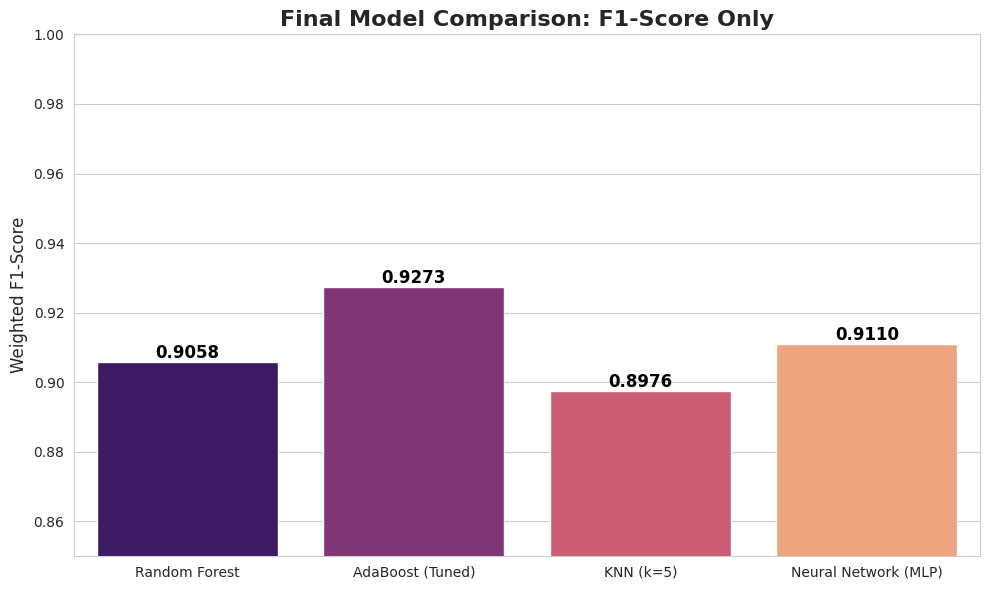


🏆 GRAND CHAMPION: AdaBoost (Tuned)
F1-Score: 0.92725
Saving and downloading AdaBoost (Tuned)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from google.colab import files

print(f"--- FINAL MODEL TOURNAMENT (Only F1-Score) ---")

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),

    'AdaBoost (Tuned)': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=8),
        n_estimators=100,
        random_state=42,
        algorithm='SAMME'
    ),

    'KNN (k=5)': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),

    'Neural Network (MLP)': make_pipeline(StandardScaler(),
                                          MLPClassifier(hidden_layer_sizes=(64, 32),
                                                        max_iter=500,
                                                        random_state=42,
                                                        early_stopping=True))
}

results_list = []

print(f"\n{'Model Name':<25} | {'F1-Score (Weighted)':<10}")
print("-" * 45)

for name, model in models.items():
    model.fit(X_train_rf, y_train_fs)

    y_pred = model.predict(X_test_rf)

    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"{name:<25} | {f1:.5f}")

    results_list.append({'Model': name, 'Score': f1})

df_res = pd.DataFrame(results_list)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.barplot(x='Model', y='Score', data=df_res, palette='magma')

plt.title('Final Model Comparison: F1-Score Only', fontsize=16, fontweight='bold')
plt.ylim(0.85, 1.0)
plt.ylabel('Weighted F1-Score', fontsize=12)
plt.xlabel('')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

plt.tight_layout()
plt.show()


best_row = df_res.sort_values(by='Score', ascending=False).iloc[0]
best_model_name = best_row['Model']
best_score = best_row['Score']

print(f"\n🏆 GRAND CHAMPION: {best_model_name}")
print(f"F1-Score: {best_score:.5f}")
print(f"Saving and downloading {best_model_name}...")

winner_model = models[best_model_name]

filename = 'best_activity_model_f1.pkl'
joblib.dump(winner_model, filename)

files.download(filename)

<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1013404704.py:21: SyntaxWarning: invalid escape sequence '\s'
  X_train = pd.read_csv('UCI HAR Dataset/train/X_train.txt', sep='\s+', header=None)
/tmp/ipython-input-1013404704.py:22: SyntaxWarning: invalid escape sequence '\s'
  y_train = pd.read_csv('UCI HAR Dataset/train/y_train.txt', sep='\s+', header=None, names=['activity_id'])
/tmp/ipython-input-1013404704.py:23: SyntaxWarning: invalid escape sequence '\s'
  X_test = pd.read_csv('UCI HAR Dataset/test/X_test.txt', sep='\s+', header=None)
/tmp/ipython-input-1013404704.py:24: SyntaxWarning: invalid escape sequenc

--- ULTIMATE FINAL CODE (SMOTE + FEATURE SELECTION + F1) ---
1. Veri Yüklendi.
2. SMOTE Uygulanıyor (Veri Dengeleniyor)...
   Orijinal: (7352, 561) -> SMOTE'lu: (8442, 561)
3. Feature Selection Yapılıyor (En iyi 102 Özellik)...
   Seçilen Özellik Sayısı: 102

--- Model Yarışı Başlıyor (Sadece F1 Score) ---
Model Name                | F1-Score  
---------------------------------------------
Random Forest             | 0.89724


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoost (Tuned)          | 0.91703
KNN (k=5)                 | 0.87529
Neural Network            | 0.92825


/tmp/ipython-input-1013404704.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='Score', data=df_res, palette='magma')


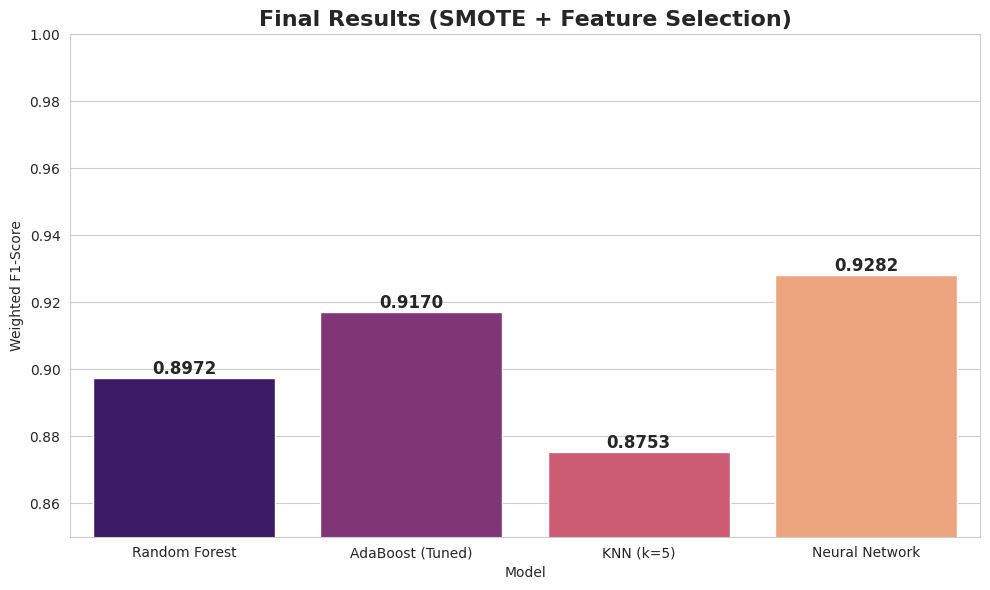


🏆 KAZANAN: Neural Network (F1: 0.92825)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE # SMOTE DAHİL!
import joblib
from google.colab import files

print("--- ULTIMATE FINAL CODE (SMOTE + FEATURE SELECTION + F1) ---")

try:
    X_train = pd.read_csv('UCI HAR Dataset/train/X_train.txt', sep='\s+', header=None)
    y_train = pd.read_csv('UCI HAR Dataset/train/y_train.txt', sep='\s+', header=None, names=['activity_id'])
    X_test = pd.read_csv('UCI HAR Dataset/test/X_test.txt', sep='\s+', header=None)
    y_test = pd.read_csv('UCI HAR Dataset/test/y_test.txt', sep='\s+', header=None, names=['activity_id'])

    y_train = y_train['activity_id']
    y_test = y_test['activity_id']
    print("1. Veri Yüklendi.")
except:
    print("HATA: Veri dosyaları yok. İndirme kodunu çalıştır.")

print("2. SMOTE Uygulanıyor (Veri Dengeleniyor)...")
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print(f"   Orijinal: {X_train.shape} -> SMOTE'lu: {X_train_bal.shape}")

print("3. Feature Selection Yapılıyor (En iyi 102 Özellik)...")
selector = SelectKBest(f_classif, k=102)
X_train_final = selector.fit_transform(X_train_bal, y_train_bal)
X_test_final = selector.transform(X_test) # Test verisine de aynı seçimi uygula
print(f"   Seçilen Özellik Sayısı: {X_train_final.shape[1]}")

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost (Tuned)': AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=8), n_estimators=100, random_state=42, algorithm='SAMME'),
    'KNN (k=5)': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    'Neural Network': make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42))
}

results_list = []
print("\n--- Model Yarışı Başlıyor (Sadece F1 Score) ---")
print(f"{'Model Name':<25} | {'F1-Score':<10}")
print("-" * 45)

for name, model in models.items():
    model.fit(X_train_final, y_train_bal)
    y_pred = model.predict(X_test_final)

    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"{name:<25} | {f1:.5f}")
    results_list.append({'Model': name, 'Score': f1})

df_res = pd.DataFrame(results_list)
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x='Model', y='Score', data=df_res, palette='magma')
plt.title('Final Results (SMOTE + Feature Selection)', fontsize=16, fontweight='bold')
plt.ylim(0.85, 1.0)
plt.ylabel('Weighted F1-Score')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

best_row = df_res.sort_values(by='Score', ascending=False).iloc[0]
best_model_name = best_row['Model']
print(f"\n🏆 KAZANAN: {best_model_name} (F1: {best_row['Score']:.5f})")

winner_model = models[best_model_name]
filename = 'best_model_smote_fs.pkl'
joblib.dump(winner_model, filename)
files.download(filename)

In [ ]:
from sklearn.model_selection import cross_val_score

print("\n--- EXPERIMENT 2: 10-FOLD CROSS VALIDATION ---")

model_cv = RandomForestClassifier(n_estimators=100, random_state=42)

scores = cross_val_score(model_cv, X_train_final, y_train_bal, cv=10, scoring='f1_weighted')

print(f"Cross-Validation Scores (10 Folds): {scores}")
print(f"Mean Accuracy: {scores.mean():.4f}")
print(f"Standard Deviation: {scores.std():.4f}")



--- EXPERIMENT 2: 10-FOLD CROSS VALIDATION ---
Cross-Validation Scores (10 Folds): [0.92532047 0.91182955 0.92625596 0.87945313 0.91825483 0.93353796
 0.93760187 0.96796652 0.97624328 0.97274807]
Mean Accuracy: 0.9349
Standard Deviation: 0.0288


/tmp/ipython-input-534372318.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=folds, y=scores, palette="viridis")


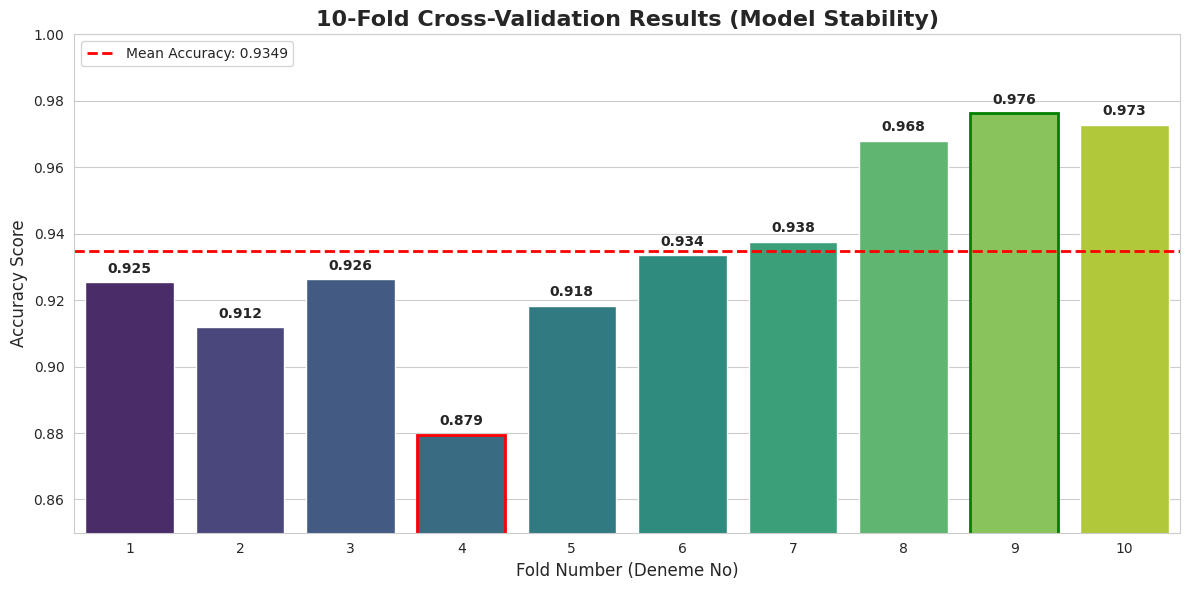

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

scores = [0.92532047, 0.91182955, 0.92625596, 0.87945313, 0.91825483,
          0.93353796, 0.93760187, 0.96796652, 0.97624328, 0.97274807]

mean_score = np.mean(scores)
folds = list(range(1, 11))

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

ax = sns.barplot(x=folds, y=scores, palette="viridis")

plt.axhline(mean_score, color='red', linestyle='--', linewidth=2, label=f'Mean Accuracy: {mean_score:.4f}')

plt.title('10-Fold Cross-Validation Results (Model Stability)', fontsize=16, fontweight='bold')
plt.xlabel('Fold Number (Deneme No)', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0.85, 1.0)
plt.legend(loc='upper left', frameon=True)

for i, v in enumerate(scores):
    ax.text(i, v + 0.002, f'{v:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

min_idx = np.argmin(scores)
max_idx = np.argmax(scores)
ax.patches[min_idx].set_edgecolor('red')
ax.patches[min_idx].set_linewidth(2)
ax.patches[max_idx].set_edgecolor('green')
ax.patches[max_idx].set_linewidth(2)

plt.tight_layout()
plt.show()

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3698923164.py:9: SyntaxWarning: invalid escape sequence '\s'
  features_df = pd.read_csv('UCI HAR Dataset/features.txt', sep='\s+', header=None, names=['index', 'name'])


--- SHAP FINAL FIX: REPLACING INDICES WITH NAMES ---


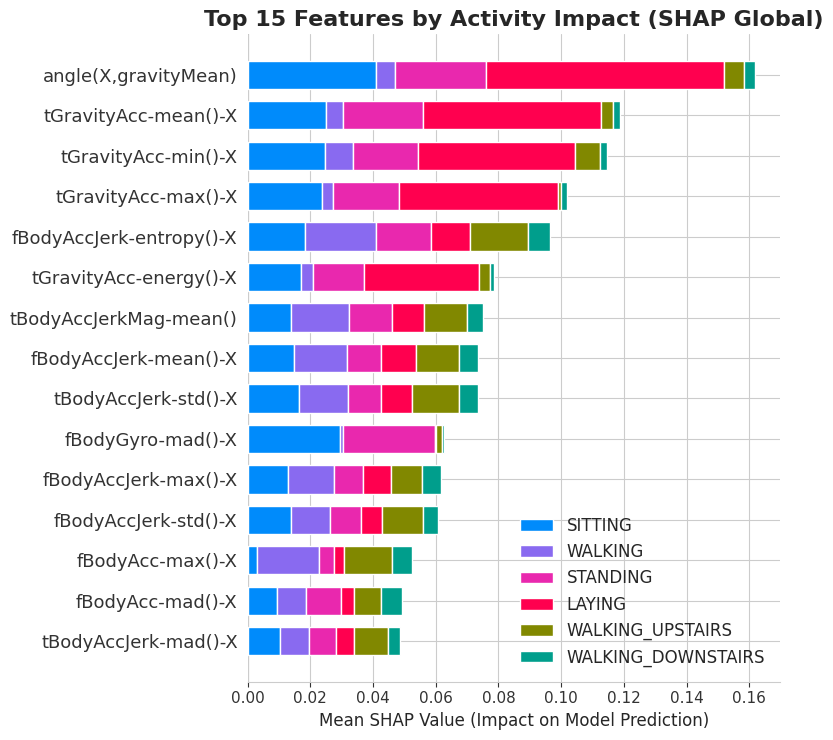

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("--- SHAP FINAL FIX: REPLACING INDICES WITH NAMES ---")

features_df = pd.read_csv('UCI HAR Dataset/features.txt', sep='\s+', header=None, names=['index', 'name'])
all_names = features_df['name'].values

selected_indices = selector.get_support()
my_feature_names = all_names[selected_indices]


activity_map = {
    1: 'WALKING',
    2: 'WALKING_UPSTAIRS',
    3: 'WALKING_DOWNSTAIRS',
    4: 'SITTING',
    5: 'STANDING',
    6: 'LAYING'
}
current_classes = models['Random Forest'].classes_
my_class_names = [activity_map[c] for c in current_classes]


X_final_df = pd.DataFrame(X_test_final[:100], columns=my_feature_names)

explainer = shap.TreeExplainer(models['Random Forest'])
shap_values = explainer.shap_values(X_final_df)

plt.figure(figsize=(12, 10))

shap.summary_plot(
    shap_values,
    X_final_df,
    class_names=my_class_names,
    max_display=15,
    plot_type="bar",
    show=False
)

plt.title("Top 15 Features by Activity Impact (SHAP Global)", fontsize=16, fontweight='bold')
plt.xlabel("Mean SHAP Value (Impact on Model Prediction)", fontsize=12)
plt.tight_layout()
plt.show()

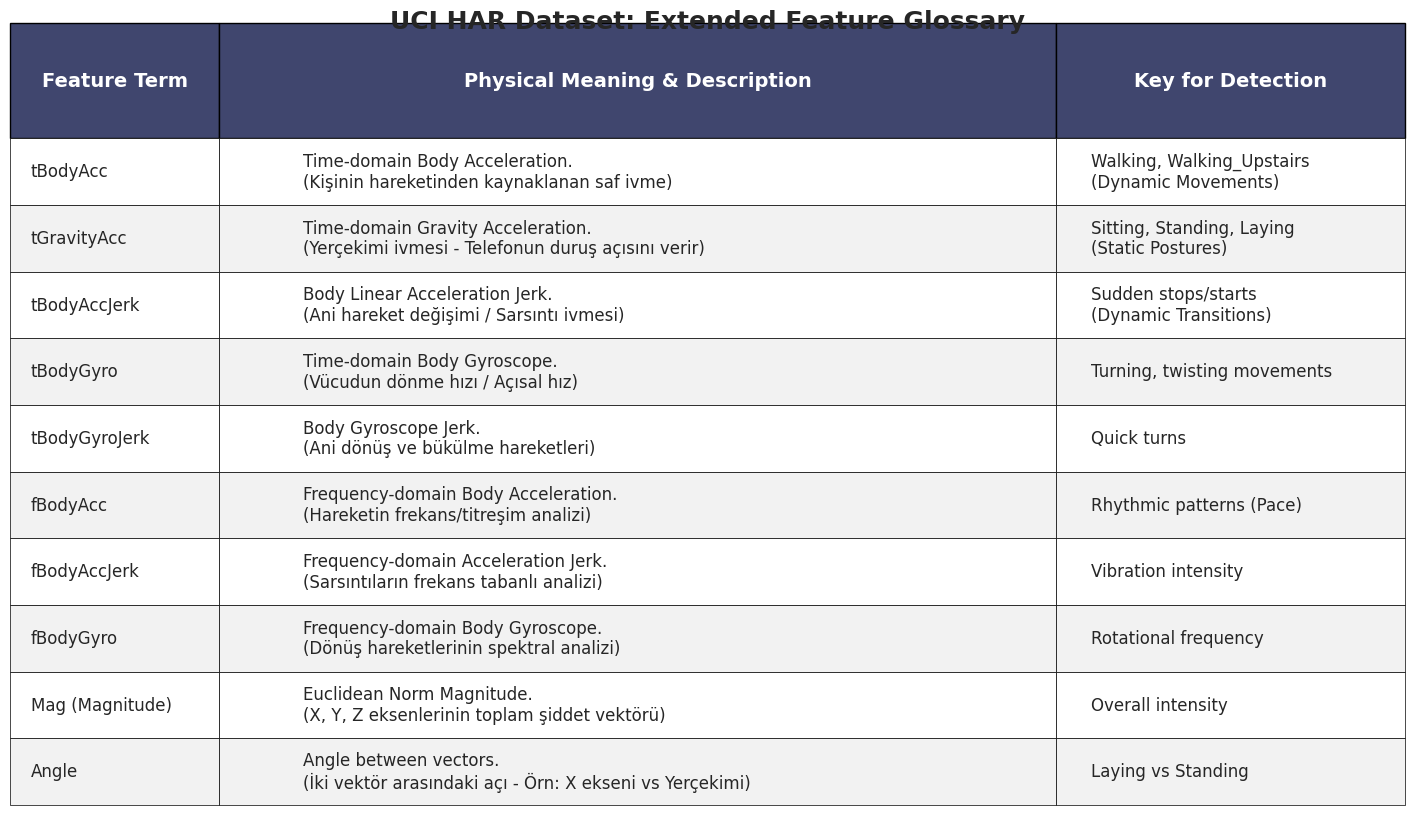

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def create_wide_feature_glossary():
    data = {
        'Feature Term': [
            'tBodyAcc',
            'tGravityAcc',
            'tBodyAccJerk',
            'tBodyGyro',
            'tBodyGyroJerk',
            'fBodyAcc',
            'fBodyAccJerk',
            'fBodyGyro',
            'Mag (Magnitude)',
            'Angle'
        ],
        'Physical Meaning & Description': [
            'Time-domain Body Acceleration.\n(Kişinin hareketinden kaynaklanan saf ivme)',
            'Time-domain Gravity Acceleration.\n(Yerçekimi ivmesi - Telefonun duruş açısını verir)',
            'Body Linear Acceleration Jerk.\n(Ani hareket değişimi / Sarsıntı ivmesi)',
            'Time-domain Body Gyroscope.\n(Vücudun dönme hızı / Açısal hız)',
            'Body Gyroscope Jerk.\n(Ani dönüş ve bükülme hareketleri)',
            'Frequency-domain Body Acceleration.\n(Hareketin frekans/titreşim analizi)',
            'Frequency-domain Acceleration Jerk.\n(Sarsıntıların frekans tabanlı analizi)',
            'Frequency-domain Body Gyroscope.\n(Dönüş hareketlerinin spektral analizi)',
            'Euclidean Norm Magnitude.\n(X, Y, Z eksenlerinin toplam şiddet vektörü)',
            'Angle between vectors.\n(İki vektör arasındaki açı - Örn: X ekseni vs Yerçekimi)'
        ],
        'Key for Detection': [
            'Walking, Walking_Upstairs\n(Dynamic Movements)',
            'Sitting, Standing, Laying\n(Static Postures)',
            'Sudden stops/starts\n(Dynamic Transitions)',
            'Turning, twisting movements',
            'Quick turns',
            'Rhythmic patterns (Pace)',
            'Vibration intensity',
            'Rotational frequency',
            'Overall intensity',
            'Laying vs Standing'
        ]
    }

    df = pd.DataFrame(data)


    fig, ax = plt.subplots(figsize=(18, 10))
    ax.axis('tight')
    ax.axis('off')

    col_widths = [0.15, 0.60, 0.25]

    table = ax.table(cellText=df.values,
                     colLabels=df.columns,
                     colWidths=col_widths,
                     cellLoc='left',
                     loc='center')

    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1, 4)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold', color='white', fontsize=14)
            cell.set_facecolor('#40466e')
            cell.set_height(0.15)
        else:
            cell.set_facecolor('#f2f2f2') if row % 2 == 0 else cell.set_facecolor('white')
            cell.set_edgecolor('black')
            cell.set_linewidth(0.5)

    plt.title('UCI HAR Dataset: Extended Feature Glossary', fontsize=18, fontweight='bold', y=0.99)
    plt.show()

create_wide_feature_glossary()